In [ ]:
#importing the stuff that will be needed for the analysis
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, confusion_matrix, roc_auc_score, precision_score, f1_score,
                    accuracy_score, roc_curve, classification_report)
import matplotlib.pyplot as plt 
import seaborn as sns 

In [13]:
dataset_test = pd.read_csv('test.csv')
dataset_training = pd.read_csv('train.csv')

In [14]:
#dropping irrelevant columns
dataset_training = dataset_training.drop(columns = ['Unnamed: 0', 'other']) 
dataset_test  = dataset_test.drop(columns = ['Unnamed: 0', 'other'])

In [15]:
#scaling the data with the continuous and not the binary columns
binary_cols = [c for c in dataset_training.columns if set(pd.unique(dataset_training[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in dataset_training.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),])

train_scaled_array = preprocess.fit_transform(dataset_training) 
test_scaled_array = preprocess.transform(dataset_test)

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=dataset_training.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=dataset_test.index)

In [16]:
#set male and female train and testing
male_train   = train_scaled[train_scaled['male'] == 1]
male_test    = test_scaled[test_scaled['male'] == 1]
female_train = train_scaled[train_scaled['female'] == 1]
female_test  = test_scaled[test_scaled['female'] == 1]

print("Male shapes:", male_train.shape, male_test.shape)
print("Female shapes:", female_train.shape, female_test.shape)

Male shapes: (31881, 15) (8071, 15)
Female shapes: (44994, 15) (11148, 15)


Experiment 1: Dropped smoking columns

In [ ]:
#drop irrelevant columns
drop_cols2 = ['diabetes', 'male', 'female', 'not current', 'ever', 'never', 'current', 'former', 'no info']

#set x and y test and train for both genders. we should have 8 variables
X_male_train = male_train.drop(columns=drop_cols2, axis = 1)
y_male_train = male_train['diabetes']
X_male_test  = male_test.drop(columns=drop_cols2, axis = 1)
y_male_test  = male_test['diabetes']

X_female_train = female_train.drop(columns=drop_cols2, axis = 1)
y_female_train = female_train['diabetes']
X_female_test  = female_test.drop(columns=drop_cols2, axis = 1)
y_female_test  = female_test['diabetes']

#logisitc regression function
lr_male   = LogisticRegression()
lr_female = LogisticRegression()

lr_male.fit(X_male_train, y_male_train)
lr_female.fit(X_female_train, y_female_train)

#metrics for females such as confusion matrix and classification report
y_pred = lr_female.predict(X_female_test)
y_prob = lr_female.predict_proba(X_female_test)[:,1]

accuracy = accuracy_score(y_female_test, y_pred) 
auc = roc_auc_score(y_female_test, y_prob)
sensitivity = recall_score(y_female_test, y_pred)
cm = confusion_matrix(y_female_test, y_pred)

print("Females:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_female_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_female_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_female_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_female_test, y_pred, pos_label=1)
}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_female_test, y_pred, target_names=['No Diabetes', 'Yes Diabetes']))


Females:
Confusion Matrix:
[[10182    77]
 [  322   567]]

                                0
Accuracy                 0.964209
Sensitivity              0.637795
Specificity              0.992494
AUC-ROC                  0.963867
Precision (No Diabetes)  0.969345
F1-Score (No Diabetes)   0.980783
Precision (Diabetes)     0.880435
F1-Score (Diabetes)      0.739726

              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     10259
Yes Diabetes       0.88      0.64      0.74       889

    accuracy                           0.96     11148
   macro avg       0.92      0.82      0.86     11148
weighted avg       0.96      0.96      0.96     11148



Males:
Confusion Matrix:
[[7143   99]
 [ 288  541]]


                                0
Accuracy                 0.952051
Sensitivity              0.652593
Specificity              0.986330
AUC-ROC                  0.959605
Precision (No Diabetes)  0.961243
F1-Score (No Diabetes)   0.973625
Precision (Diabetes)     0.845313
F1-Score (Diabetes)      0.736555

              precision    recall  f1-score   support

 No Diabetes       0.96      0.99      0.97      7242
Yes Diabetes       0.85      0.65      0.74       829

    accuracy                           0.95      8071
   macro avg       0.90      0.82      0.86      8071
weighted avg       0.95      0.95      0.95      8071

                         Male    Female
HbA1c_level          2.436806  2.553291
blood_glucose_level  1.366588  1.363056
age                  1.073445  1.021249
hypertension         0.761803  0.837708
bmi                  0.601819  0.604486
heart_disease        0.575402  0.828188


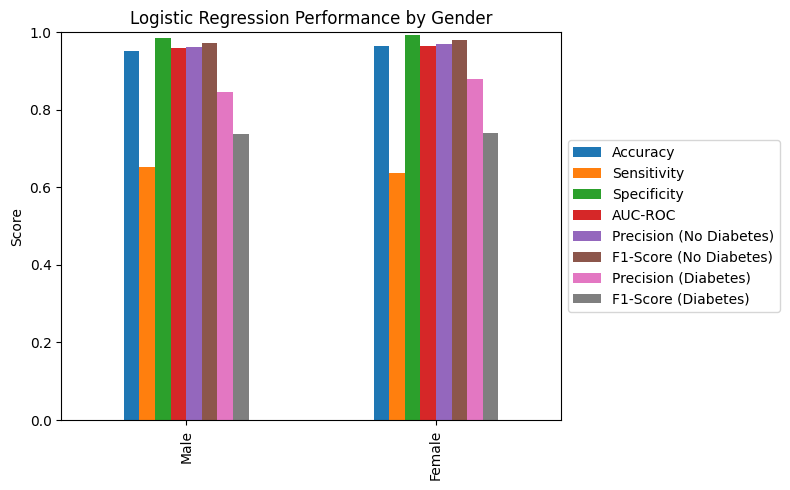

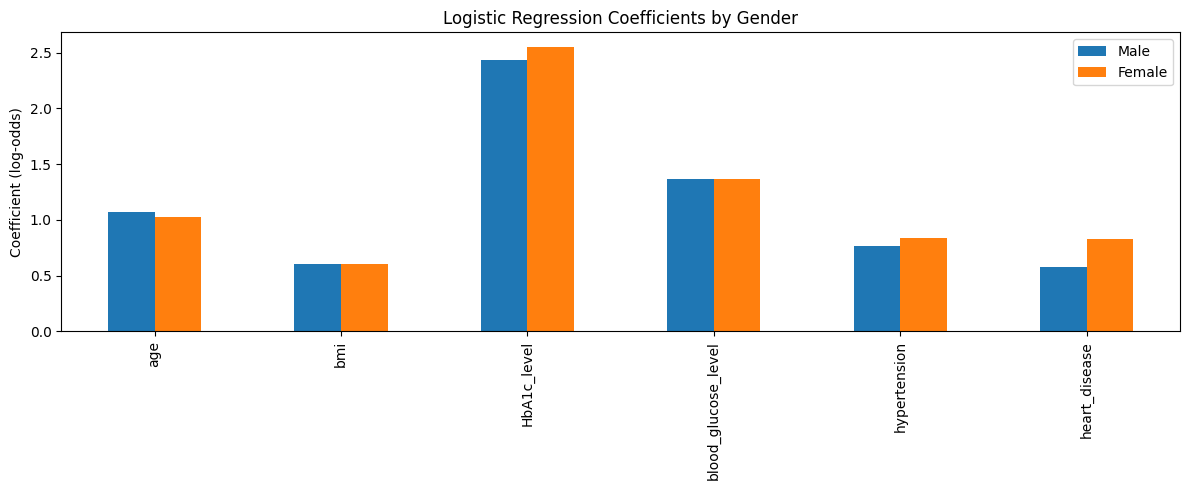

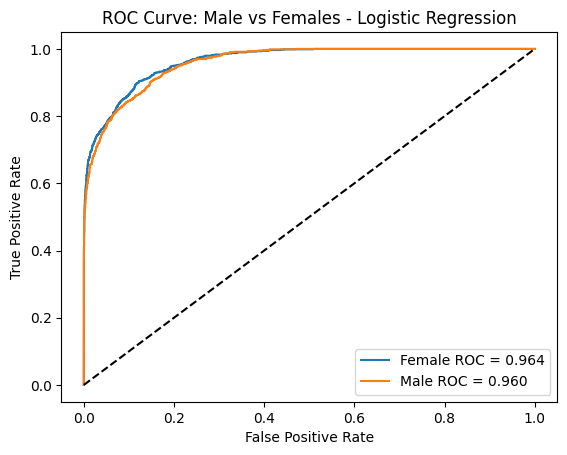

In [18]:
#metrics for males such as confusion matrix and classification report
y_pred2 = lr_male.predict(X_male_test)
y_prob2 = lr_male.predict_proba(X_male_test)[:,1]

accuracy = accuracy_score(y_male_test, y_pred2) 
auc2 = roc_auc_score(y_male_test, y_prob2)
sensitivity = recall_score(y_male_test, y_pred2)
cm = confusion_matrix(y_male_test, y_pred2)

print("Males:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary2 = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc2,
    'Precision (No Diabetes)': precision_score(y_male_test, y_pred2, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_male_test, y_pred2, pos_label=0),
    'Precision (Diabetes)': precision_score(y_male_test, y_pred2, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_male_test, y_pred2, pos_label=1)
}

print()

metrics_df2 = pd.DataFrame([metrics_summary2])
print(metrics_df2.T)
print()

print(classification_report(y_male_test, y_pred2, target_names=['No Diabetes', 'Yes Diabetes']))

#coefficients for each variable in each gender
coef_male   = pd.Series(lr_male.coef_[0], index=X_male_train.columns, name='Male')
coef_female = pd.Series(lr_female.coef_[0], index=X_female_train.columns, name='Female')

coef_compare = pd.concat([coef_male, coef_female], axis=1)
print(coef_compare.sort_values(by=['Male','Female'], key=abs, ascending=False))

metrics_df3 = pd.concat([metrics_df2, metrics_df], axis=0)
metrics_df3.index = ['Male', 'Female']

#plots
#performance in logistic regression with the metrics for each gender
ax = metrics_df3.plot.bar(figsize=(8,5))
ax.set_title("Logistic Regression Performance by Gender")
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

#coefficients plot for each variable for each gender
coef_compare[['Male','Female']].plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients by Gender")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

#ROC curve to compare gender
fpr, tpr, thresholds = roc_curve(y_female_test, y_prob) 
fpr2, tpr2, thresholds2 = roc_curve(y_male_test, y_prob2) 
plt.plot(fpr, tpr, label=f"Female ROC = {auc:.3f}")
plt.plot(fpr2, tpr2, label=f"Male ROC = {auc2:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Male vs Females - Logistic Regression")
plt.legend()
plt.show()

###################################################################################

Experiment 2: Dropped Hypertension

In [19]:
#drop columns that we will not use for the analysis
drop_cols = ['diabetes', 'male', 'female', 'hypertension']

X_male_train = male_train.drop(columns=drop_cols, axis = 1)
y_male_train = male_train['diabetes']
X_male_test  = male_test.drop(columns=drop_cols, axis = 1)
y_male_test  = male_test['diabetes']

X_female_train = female_train.drop(columns=drop_cols, axis = 1)
y_female_train = female_train['diabetes']
X_female_test  = female_test.drop(columns=drop_cols, axis = 1)
y_female_test  = female_test['diabetes']

#logisitc regression function
lr_male   = LogisticRegression()
lr_female = LogisticRegression()

lr_male.fit(X_male_train, y_male_train)
lr_female.fit(X_female_train, y_female_train)

#metrics for females such as confusion matrix and classification report
y_pred = lr_female.predict(X_female_test)
y_prob = lr_female.predict_proba(X_female_test)[:,1]

accuracy = accuracy_score(y_female_test, y_pred) 
auc = roc_auc_score(y_female_test, y_prob)
sensitivity = recall_score(y_female_test, y_pred)
cm = confusion_matrix(y_female_test, y_pred)

print("Females:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_female_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_female_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_female_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_female_test, y_pred, pos_label=1)
}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_female_test, y_pred, target_names=['No Diabetes', 'Yes Diabetes']))


Females:
Confusion Matrix:
[[10188    71]
 [  326   563]]

                                0
Accuracy                 0.964388
Sensitivity              0.633296
Specificity              0.993079
AUC-ROC                  0.963686
Precision (No Diabetes)  0.968994
F1-Score (No Diabetes)   0.980889
Precision (Diabetes)     0.888013
F1-Score (Diabetes)      0.739330

              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     10259
Yes Diabetes       0.89      0.63      0.74       889

    accuracy                           0.96     11148
   macro avg       0.93      0.81      0.86     11148
weighted avg       0.96      0.96      0.96     11148



Males:
Confusion Matrix:
[[7160   82]
 [ 294  535]]


                                0
Accuracy                 0.953413
Sensitivity              0.645356
Specificity              0.988677
AUC-ROC                  0.959698
Precision (No Diabetes)  0.960558
F1-Score (No Diabetes)   0.974415
Precision (Diabetes)     0.867099
F1-Score (Diabetes)      0.739972

              precision    recall  f1-score   support

 No Diabetes       0.96      0.99      0.97      7242
Yes Diabetes       0.87      0.65      0.74       829

    accuracy                           0.95      8071
   macro avg       0.91      0.82      0.86      8071
weighted avg       0.95      0.95      0.95      8071

                         Male    Female
HbA1c_level          2.455288  2.547821
blood_glucose_level  1.357197  1.361047
no info             -1.171895 -1.181399
age                  1.110979  1.096038
not current         -0.923254 -0.738723
heart_disease        0.641632  0.858951
bmi                  0.602588  0

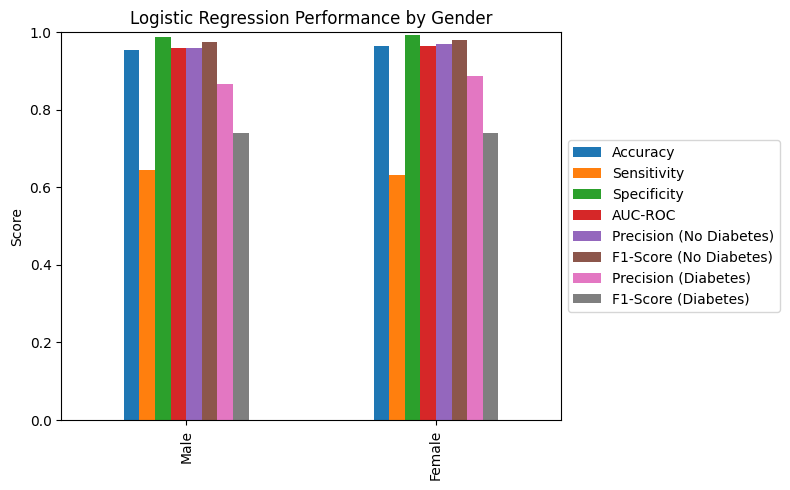

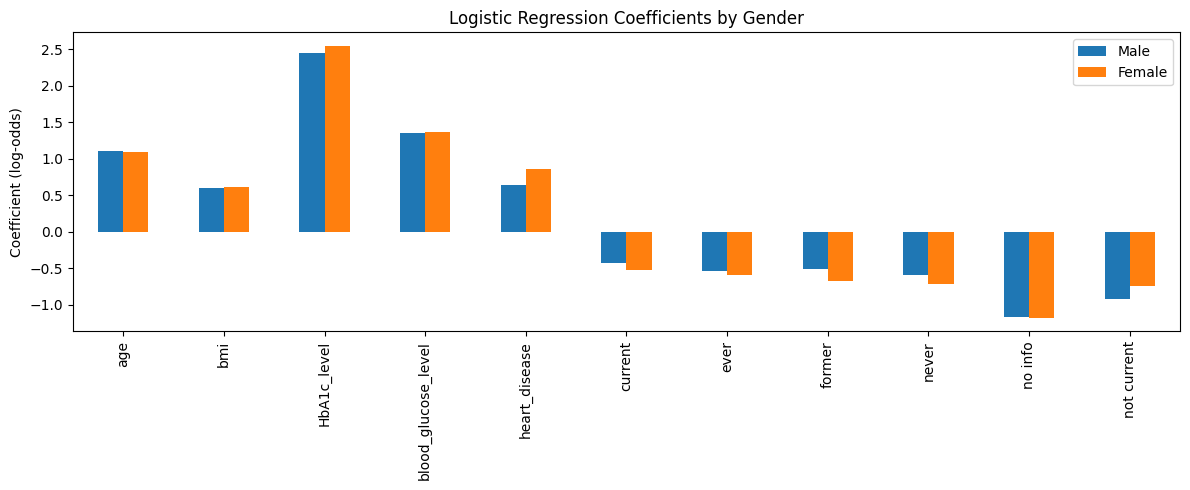

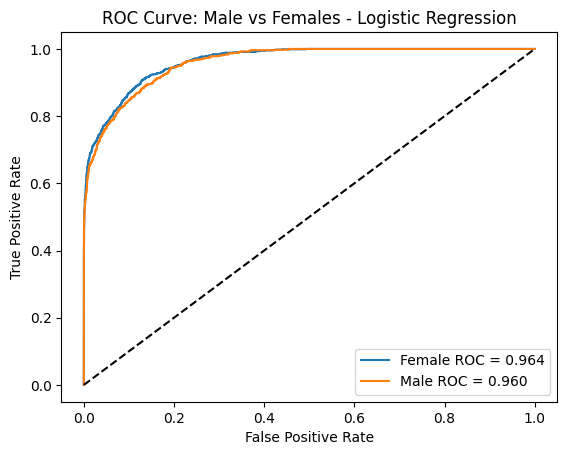

In [20]:
#metrics for males such as confusion matrix and classification report
y_pred2 = lr_male.predict(X_male_test)
y_prob2 = lr_male.predict_proba(X_male_test)[:,1]

accuracy = accuracy_score(y_male_test, y_pred2) 
auc2 = roc_auc_score(y_male_test, y_prob2)
sensitivity = recall_score(y_male_test, y_pred2)
cm = confusion_matrix(y_male_test, y_pred2)

print("Males:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary2 = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc2,
    'Precision (No Diabetes)': precision_score(y_male_test, y_pred2, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_male_test, y_pred2, pos_label=0),
    'Precision (Diabetes)': precision_score(y_male_test, y_pred2, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_male_test, y_pred2, pos_label=1)
}

print()

metrics_df2 = pd.DataFrame([metrics_summary2])
print(metrics_df2.T)
print()

print(classification_report(y_male_test, y_pred2, target_names=['No Diabetes', 'Yes Diabetes']))

#coefficients for each variable in each gender
coef_male   = pd.Series(lr_male.coef_[0], index=X_male_train.columns, name='Male')
coef_female = pd.Series(lr_female.coef_[0], index=X_female_train.columns, name='Female')

coef_compare = pd.concat([coef_male, coef_female], axis=1)
print(coef_compare.sort_values(by=['Male','Female'], key=abs, ascending=False))

metrics_df3 = pd.concat([metrics_df2, metrics_df], axis=0)
metrics_df3.index = ['Male', 'Female']

#plots
#performance in logistic regression with the metrics for each gender
ax = metrics_df3.plot.bar(figsize=(8,5))
ax.set_title("Logistic Regression Performance by Gender")
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

#coefficients plot for each variable for each gender
coef_compare[['Male','Female']].plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients by Gender")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

#ROC curve to compare gender
fpr, tpr, thresholds = roc_curve(y_female_test, y_prob) 
fpr2, tpr2, thresholds2 = roc_curve(y_male_test, y_prob2) 
plt.plot(fpr, tpr, label=f"Female ROC = {auc:.3f}")
plt.plot(fpr2, tpr2, label=f"Male ROC = {auc2:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Male vs Females - Logistic Regression")
plt.legend()
plt.show()

###########################################################

Experiment 3: Dropped heart disease

In [21]:
#drop columns that we will not use for the analysis
drop_cols = ['diabetes', 'male', 'female', 'heart_disease']

X_male_train = male_train.drop(columns=drop_cols, axis = 1)
y_male_train = male_train['diabetes']
X_male_test  = male_test.drop(columns=drop_cols, axis = 1)
y_male_test  = male_test['diabetes']

X_female_train = female_train.drop(columns=drop_cols, axis = 1)
y_female_train = female_train['diabetes']
X_female_test  = female_test.drop(columns=drop_cols, axis = 1)
y_female_test  = female_test['diabetes']

#logisitc regression function
lr_male   = LogisticRegression()
lr_female = LogisticRegression()

lr_male.fit(X_male_train, y_male_train)
lr_female.fit(X_female_train, y_female_train)

#metrics for females such as confusion matrix and classification report
y_pred = lr_female.predict(X_female_test)
y_prob = lr_female.predict_proba(X_female_test)[:,1]

accuracy = accuracy_score(y_female_test, y_pred) 
auc = roc_auc_score(y_female_test, y_prob)
sensitivity = recall_score(y_female_test, y_pred)
cm = confusion_matrix(y_female_test, y_pred)

print("Females:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_female_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_female_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_female_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_female_test, y_pred, pos_label=1)
}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_female_test, y_pred, target_names=['No Diabetes', 'Yes Diabetes']))


Females:
Confusion Matrix:
[[10184    75]
 [  324   565]]

                                0
Accuracy                 0.964209
Sensitivity              0.635546
Specificity              0.992689
AUC-ROC                  0.964052
Precision (No Diabetes)  0.969166
F1-Score (No Diabetes)   0.980787
Precision (Diabetes)     0.882812
F1-Score (Diabetes)      0.739045

              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     10259
Yes Diabetes       0.88      0.64      0.74       889

    accuracy                           0.96     11148
   macro avg       0.93      0.81      0.86     11148
weighted avg       0.96      0.96      0.96     11148



Males:
Confusion Matrix:
[[7155   87]
 [ 290  539]]


                                0
Accuracy                 0.953290
Sensitivity              0.650181
Specificity              0.987987
AUC-ROC                  0.959104
Precision (No Diabetes)  0.961048
F1-Score (No Diabetes)   0.974331
Precision (Diabetes)     0.861022
F1-Score (Diabetes)      0.740893

              precision    recall  f1-score   support

 No Diabetes       0.96      0.99      0.97      7242
Yes Diabetes       0.86      0.65      0.74       829

    accuracy                           0.95      8071
   macro avg       0.91      0.82      0.86      8071
weighted avg       0.95      0.95      0.95      8071

                         Male    Female
HbA1c_level          2.445950  2.546627
blood_glucose_level  1.363899  1.365711
no info             -1.137609 -1.167981
age                  1.126219  1.080130
not current         -0.892829 -0.752072
hypertension         0.710301  0.822923
never               -0.628028 -0

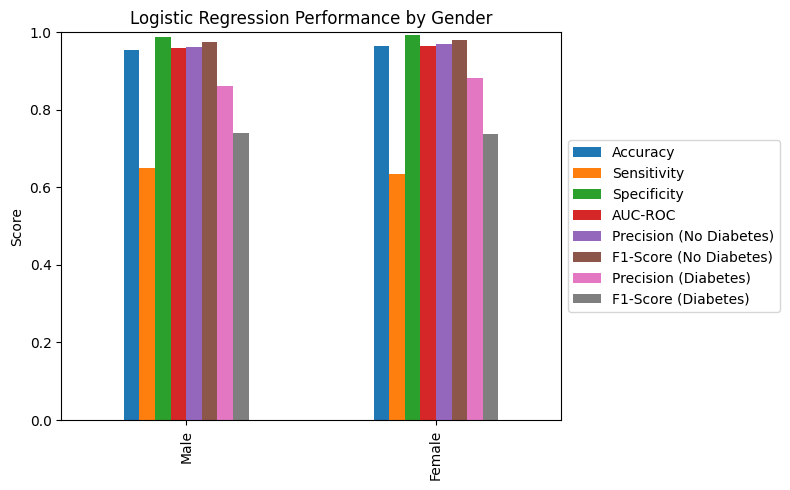

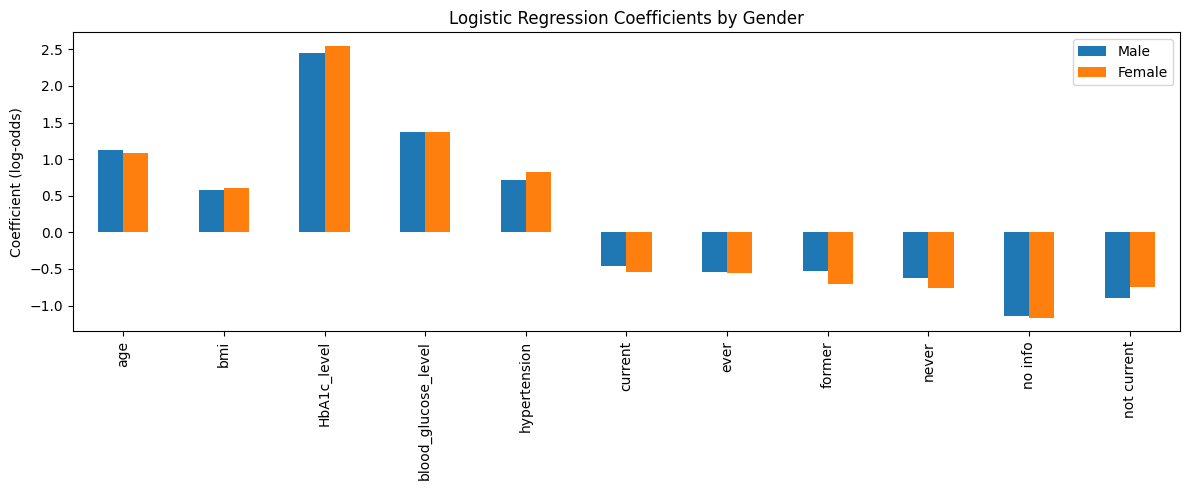

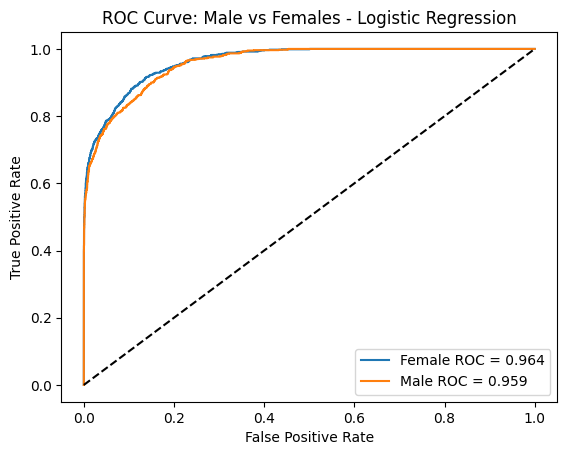

In [22]:
#metrics for males such as confusion matrix and classification report
y_pred2 = lr_male.predict(X_male_test)
y_prob2 = lr_male.predict_proba(X_male_test)[:,1]

accuracy = accuracy_score(y_male_test, y_pred2) 
auc2 = roc_auc_score(y_male_test, y_prob2)
sensitivity = recall_score(y_male_test, y_pred2)
cm = confusion_matrix(y_male_test, y_pred2)

print("Males:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary2 = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc2,
    'Precision (No Diabetes)': precision_score(y_male_test, y_pred2, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_male_test, y_pred2, pos_label=0),
    'Precision (Diabetes)': precision_score(y_male_test, y_pred2, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_male_test, y_pred2, pos_label=1)
}

print()

metrics_df2 = pd.DataFrame([metrics_summary2])
print(metrics_df2.T)
print()

print(classification_report(y_male_test, y_pred2, target_names=['No Diabetes', 'Yes Diabetes']))

#coefficients for each variable in each gender
coef_male   = pd.Series(lr_male.coef_[0], index=X_male_train.columns, name='Male')
coef_female = pd.Series(lr_female.coef_[0], index=X_female_train.columns, name='Female')

coef_compare = pd.concat([coef_male, coef_female], axis=1)
print(coef_compare.sort_values(by=['Male','Female'], key=abs, ascending=False))

metrics_df3 = pd.concat([metrics_df2, metrics_df], axis=0)
metrics_df3.index = ['Male', 'Female']

#plots
#performance in logistic regression with the metrics for each gender
ax = metrics_df3.plot.bar(figsize=(8,5))
ax.set_title("Logistic Regression Performance by Gender")
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

#coefficients plot for each variable for each gender
coef_compare[['Male','Female']].plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients by Gender")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

#ROC curve to compare gender
fpr, tpr, thresholds = roc_curve(y_female_test, y_prob) 
fpr2, tpr2, thresholds2 = roc_curve(y_male_test, y_prob2) 
plt.plot(fpr, tpr, label=f"Female ROC = {auc:.3f}")
plt.plot(fpr2, tpr2, label=f"Male ROC = {auc2:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Male vs Females - Logistic Regression")
plt.legend()
plt.show()